# Ⅰ第1回 GW3 試行①　MLP × FashionMNIST

教科書のコード 12 枚が，授業ページ GW3 のカード A〜L に **順不同・番号なし** で載っている．下の①〜⑫の空のセルに貼って組み立てる．

1. GW2-1 のシートを横に開き，①〜⑫の見出しに GW2-1 のカード名（例：ライブラリのインポート，損失関数の定義）を写す
2. カード名ごとに，その仕事をするコードを A〜L から探して貼る（コメントが手がかり）
3. 上から実行し，最後の「記録」のセルまで実行する

LLM に順番を聞く前に，まず自分で読む．


## (0) グループと役割の設定

In [1]:
# ===== (0) グループと役割の設定 =====
GROUP_ID = 16                  # ← 自分のグループ番号 (1〜27) に書き換える
MEMBER_ROLE = "recorder"   # implementer / verifier / recorder / presenter（5 人グループは collector も）のいずれか．3 人グループで presenter を兼ねる verifier は "verifier"

# 授業用フォルダ（AI_TD）のルートを import パスに追加する（ノートブックをどこから開いても動く）
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / ".dlcourse_root").exists())
sys.path.insert(0, str(ROOT))
print("作業フォルダ:", ROOT)

作業フォルダ: /Users/yamato/AI_TD


## コードを貼るセル（①〜⑫）

見出しに GW2-1 のカード名を写してから，合うコードを下の空のセルに貼る．

## データ準備フェーズ（①〜④）

### コードテンプレート①

カード名： L　カード：ライブラリのインポート

In [2]:
# PyTorch 本体と，ニューラルネットワーク・最適化・画像処理の部品を読み込む
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

# グラフを描く道具
import matplotlib.pyplot as plt
import seaborn as sns
# 処理の進み具合をバーで表示する道具
from tqdm import tqdm
import random
import numpy as np

### コードテンプレート②

カード名：B　カード：データの前処理

In [3]:
# 前処理：画像をテンソル（0〜1 の数値の配列）に変換する
data_transform = transforms.Compose([
    transforms.ToTensor(),
])

### コードテンプレート③

カード名：I　カード：データセットの準備

In [4]:
# 乱数の種を固定して，同じ条件の結果を再現しやすくする（機種や版が違うと一致しないこともある）
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed(0)
if torch.backends.mps.is_available():
    torch.mps.manual_seed(0)

# FashionMNIST の訓練用データ（6 万枚）を読み込む（初回はダウンロードする）
train_val_dataset = datasets.FashionMNIST(
    root=str(ROOT / 'assets' / 'data'), 
    train=True, 
    download=True, 
    transform=data_transform
)
# テスト用データ（1 万枚．学習には使わない）を読み込む
test_dataset = datasets.FashionMNIST(
    root=str(ROOT / 'assets' / 'data'),
    train=False,
    download=True,
    transform=data_transform
)

# 訓練用データを 8:2 に分け，2 割を検証用にする
train_size = int(0.8 * len(train_val_dataset))
val_size = len(train_val_dataset) - train_size
train_dataset, val_dataset = random_split(
    train_val_dataset, 
    [train_size, val_size]
)
print(f"訓練データ数: {len(train_dataset)} 枚")
print(f"検証データ数: {len(val_dataset)} 枚")
print(f"テストデータ数: {len(test_dataset)} 枚")

訓練データ数: 48000 枚
検証データ数: 12000 枚
テストデータ数: 10000 枚


### コードテンプレート④

カード名：F　カード：データローダの作成

In [5]:
# 一度にまとめて流す枚数（ミニバッチの大きさ）
BATCH_SIZE = 64
# データをミニバッチに分けて順に取り出す仕組み（訓練用は毎回並びを混ぜる）
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## 学習設定フェーズ（⑤〜⑨）

### コードテンプレート⑤

カード名：D　カード：デバイスの設定

In [6]:
# 計算に使う装置を選ぶ：NVIDIA の GPU → Apple の GPU（mps）→ CPU の順
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"使用デバイス: {device}")

使用デバイス: mps


### コードテンプレート⑥

カード名：C　カード：入力データの形状確認

ミニバッチサイズ: 64
チャネル数: 1
画像の高さ: 28
画像の幅: 28
torch.Size([64, 1, 28, 28])


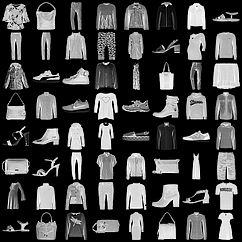

In [7]:
# ミニバッチを 1 つ取り出し，形（枚数・チャネル・高さ・幅）を確かめる
imgs, _ = next(iter(train_loader))
c, h, w = imgs[0].shape
print("ミニバッチサイズ:", len(imgs))
print("チャネル数:", c)
print("画像の高さ:", h)
print("画像の幅:", w)
print(imgs.shape)

# 取り出した画像を並べて表示する
img = torchvision.utils.make_grid(imgs)
img = transforms.functional.to_pil_image(img)
display(img)

### コードテンプレート⑦

カード名：G　カード：ネットワークの定義

In [8]:
# 入力の数 = チャネル × 高さ × 幅（画像を 1 列に並べたときの長さ）
INPUT_SIZE = c * h * w
# 中間層（隠れ層）のニューロンの数
HIDDEN_SIZE1 = 512
HIDDEN_SIZE2 = 256
# 出力の数 = 分類するクラスの数
OUTPUT_SIZE = 10

# 層を上から順に積み重ねてモデルを作る
model = nn.Sequential(
    # 画像（または特徴マップ）を 1 列のベクトルに伸ばす
    nn.Flatten(),
    # 全結合層：すべての入力とつながる
    nn.Linear(INPUT_SIZE, HIDDEN_SIZE1),
    # 活性化関数：負の値を 0 にする
    nn.ReLU(),
    nn.Linear(HIDDEN_SIZE1, HIDDEN_SIZE2),
    nn.ReLU(),
    nn.Linear(HIDDEN_SIZE2, OUTPUT_SIZE)
)
# モデルを計算装置に載せる
model.to(device)

model

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=256, bias=True)
  (4): ReLU()
  (5): Linear(in_features=256, out_features=10, bias=True)
)

### コードテンプレート⑧

カード名：A　カード：損失関数の定義

In [9]:
# 損失関数：予測と正解のずれを測る（分類で標準の交差エントロピー）
criterion = nn.CrossEntropyLoss()

### コードテンプレート⑨

カード名：J　カード：最適化関数の定義

In [10]:
# 最適化手法：損失が小さくなる向きに重みを少しずつ動かす（学習率 0.001）
optimizer = optim.Adam(model.parameters(), lr=0.001)

## 学習・評価フェーズ（⑩〜⑫）

### コードテンプレート⑩

カード名：E　カード：モデル学習&検証

In [11]:
EPOCHS = 20          # 授業では試行①②③とも 20 エポックにそろえる
# エポックごとの損失と正解率を記録するリスト
train_loss_list = []
val_loss_list = []
train_acc_list = []
val_acc_list = []

# 学習時間を測る（授業で追加）
import time
_t0 = time.perf_counter()
# EPOCHS 回，訓練データ全体を繰り返し学習する
for epoch in range(EPOCHS):
    # 訓練モードにする
    model.train()
    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Train]', leave=False):
        images, labels = images.to(device), labels.to(device)

        # 前回の勾配を消す → 予測 → 損失を計算 → 誤差逆伝播で勾配を求める → 重みを更新
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        train_loss += loss.item() * images.size(0)
        # 最も確率の高いクラスを予測とし，正解の数を数える
        _, predicted = torch.max(outputs.data, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()
    
    train_loss /= train_total
    train_accuracy = 100.0 * train_correct / train_total
    train_loss_list.append(train_loss)
    train_acc_list.append(train_accuracy)
    
    # 評価モードにする：ここからは検証データで確かめる（重みは更新しない）
    model.eval()
    val_loss = 0.0
    val_correct = 0
    val_total = 0
    
    # 勾配を計算しない（評価だけなので速く，メモリも少なくて済む）
    with torch.no_grad():
        for images, labels in tqdm(val_loader, desc=f'Epoch {epoch+1}/{EPOCHS} [Val]', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()
    
    val_loss /= val_total
    val_accuracy = 100.0 * val_correct / val_total
    val_loss_list.append(val_loss)
    val_acc_list.append(val_accuracy)

    # エポックごとの損失と正解率を表示する
    print(f'Epoch {epoch+1}/{EPOCHS},'
          f'Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.2f}%,'
          f'Val Loss: {val_loss:.4f}, Val Acc: {val_accuracy:.2f}%  ')

train_sec = time.perf_counter() - _t0
print(f'学習時間: {train_sec:.1f} 秒')

Epoch 1/20,Train Loss: 0.5194, Train Acc: 81.48%,Val Loss: 0.4101, Val Acc: 84.62%  


Epoch 2/20,Train Loss: 0.3739, Train Acc: 86.39%,Val Loss: 0.3670, Val Acc: 86.49%  


Epoch 3/20,Train Loss: 0.3350, Train Acc: 87.63%,Val Loss: 0.3346, Val Acc: 87.87%  


Epoch 4/20,Train Loss: 0.3075, Train Acc: 88.58%,Val Loss: 0.3168, Val Acc: 88.09%  


Epoch 5/20,Train Loss: 0.2876, Train Acc: 89.38%,Val Loss: 0.3151, Val Acc: 88.39%  


...

Epoch 16/20,Train Loss: 0.1748, Train Acc: 93.30%,Val Loss: 0.3048, Val Acc: 89.74%  


Epoch 17/20,Train Loss: 0.1685, Train Acc: 93.68%,Val Loss: 0.3218, Val Acc: 89.83%  


Epoch 18/20,Train Loss: 0.1616, Train Acc: 93.78%,Val Loss: 0.3382, Val Acc: 89.33%  


Epoch 19/20,Train Loss: 0.1548, Train Acc: 94.09%,Val Loss: 0.3369, Val Acc: 89.43%  


Epoch 20/20,Train Loss: 0.1509, Train Acc: 94.24%,Val Loss: 0.3419, Val Acc: 89.53%  
学習時間: 83.5 秒


### コードテンプレート⑪

カード名：K　カード：学習結果の可視化

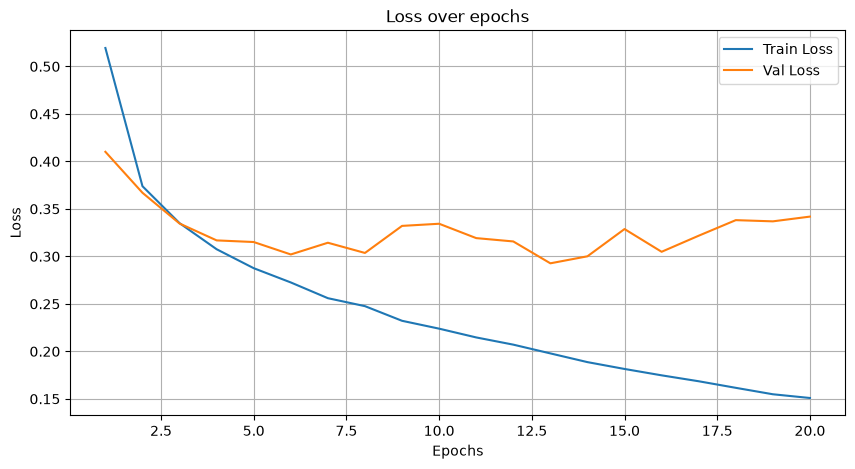

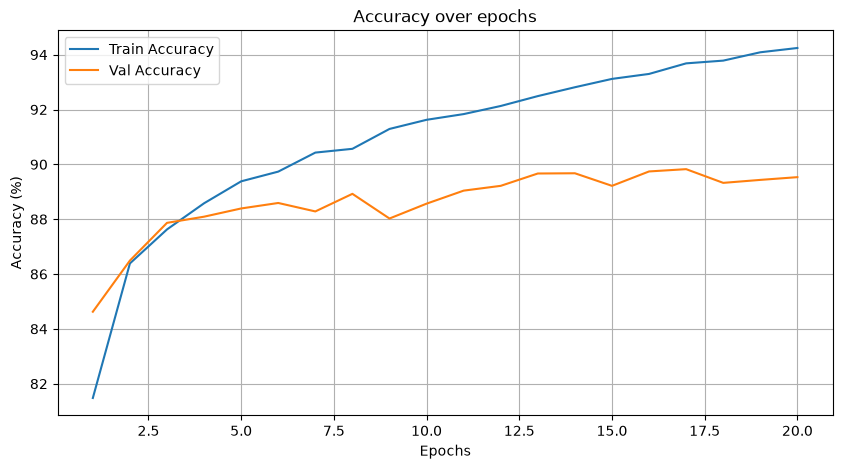

In [12]:
import seaborn as sns
# グラフを描く道具
import matplotlib.pyplot as plt
# 損失と正解率の推移をグラフにする（訓練と検証を比べる）
epochs = range(1, len(train_loss_list) + 1)
plt.figure(figsize=(10, 5))

sns.lineplot(x=epochs, y=train_loss_list, label='Train Loss')
sns.lineplot(x=epochs, y=val_loss_list, label='Val Loss')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(10, 5))
sns.lineplot(x=epochs, y=train_acc_list, label='Train Accuracy')
sns.lineplot(x=epochs, y=val_acc_list, label='Val Accuracy')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.show()

### コードテンプレート⑫

カード名：H　カード：モデルの性能評価

In [13]:
model.eval()   # 評価モード（学習のときだけ働く Dropout などを止める）
# テストデータ（学習にも検証にも使っていないデータ）で正解率を求める
correct = 0
total = 0
# 勾配を計算しない（評価だけなので速く，メモリも少なくて済む）
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        # 最も確率の高いクラスを予測とし，正解の数を数える
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Accuracy: {correct / total * 100:.2f}% ')

Accuracy: 88.80% 


## 記録

下のセルで結果を CSV に残す（試行①②③とも同じ CSV に行が増える）．討議の問いは授業ページ GW3 にある．


In [14]:
# 試行①②③のどれを実行したかを自動で判定して記録する（3 回とも同じ CSV に行が増える）
from common.logger import ResultLogger
data_name = "Cable1" if "IMAGE_DIR" in globals() else "FashionMNIST"
arch = "CNN" if any(isinstance(m, nn.Conv2d) for m in model.modules()) else "MLP"
metrics = {"epochs": EPOCHS, "train_sec": train_sec,
           "val_acc_best": max(val_acc_list) / 100, "val_acc_last": val_acc_list[-1] / 100}
if data_name == "FashionMNIST":
    metrics["test_accuracy"] = correct / total
logger = ResultLogger(GROUP_ID, MEMBER_ROLE, course="c1", day="d1", exercise="ex0", device=device)
logger.log_many(metrics, condition=f"{data_name}_{arch}", seed=0)
print("書き込み先:", logger.path)
print(f"{data_name} × {arch}  検証正解率 最高 {max(val_acc_list):.2f}% / 最終 {val_acc_list[-1]:.2f}%"
      f"  学習時間 {train_sec:.1f} 秒  エポック {EPOCHS}")

書き込み先: /Users/yamato/AI_TD/results/c1_d1_ex0_16.csv
FashionMNIST × MLP  検証正解率 最高 89.83% / 最終 89.53%  学習時間 83.5 秒  エポック 20
